# Milestone 5 (v0.2)

In [1]:
import sys, copy, json, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
ROOT = Path.cwd()
sys.path.insert(0, str(ROOT))

from gridfm import dataset as ds, encoding as enc, evaluate as ev, train as tr
from gridfm.model import GridFMv02
from torch_geometric.loader import DataLoader

RAW_DIR, PROC_DIR = ROOT / "data" / "raw", ROOT / "data" / "processed"
CKPT_DIR = ROOT / "checkpoints"
M6_STATS = ROOT / "results" / "m6_stats"          # committed v0.1 results (frozen)
FIG_DIR = ROOT / "results" / "figures" / "v02_m5"
STATS_DIR = ROOT / "results" / "v02_m5_stats"
for d in [FIG_DIR, STATS_DIR]:
    d.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BASE39 = json.load(open(ROOT / "results" / "m2_stats" / "base_mva.json"))["case39"]
train39 = enc.concat_rwpe(ds.load_processed(PROC_DIR, "case39", "train"))
val39 = enc.concat_rwpe(ds.load_processed(PROC_DIR, "case39", "val"))
test39 = enc.concat_rwpe(ds.load_processed(PROC_DIR, "case39", "test"))
print("device %s | case39 splits: %d / %d / %d | base %.0f MVA"
      % (DEVICE, len(train39), len(val39), len(test39), BASE39))

def load_pretrained_v02():
    m = GridFMv02()
    st = torch.load(CKPT_DIR / "final_pretrain_v02_best.pt", weights_only=False)
    m.load_state_dict(st["model"])
    return m

# committed v0.1 numbers for pairing
dc39 = pd.read_csv(M6_STATS / "dc_case39.csv")
zs01 = pd.read_csv(M6_STATS / "zeroshot_case39.csv")
sc01 = pd.read_csv(M6_STATS / "scoreboard_case39.csv", index_col=0)
curves01 = json.load(open(M6_STATS / "ft_curves.json"))
frac01 = json.load(open(M6_STATS / "data_efficiency.json"))

device cuda | case39 splits: 977 / 126 / 120 | base 1100 MVA

## Question 1 — Zero-shot: an unseen grid, no training

In [2]:
model_zs = load_pretrained_v02()
zs_df, zs_det, _ = ev.pf_evaluate(model_zs, test39, device=DEVICE)
print("zero-shot case39:  v0.2 mean Pr %.1f MW | Qr %.1f MVar" %
      (zs_df.p_res_mw.mean(), zs_df.q_res_mvar.mean()))
print("                   v0.1 committed: Pr %.1f MW | Qr %.1f MVar" %
      (zs01.p_res_mw.mean(), zs01.q_res_mvar.mean()))
zs_df.to_csv(STATS_DIR / "zeroshot_case39.csv", index=False)

zero-shot case39:  v0.2 mean Pr 395.0 MW | Qr 136.4 MVar

                   v0.1 committed: Pr 866.7 MW | Qr 338.3 MVar

## Question 2 — Fine-tuning: pretrained head start vs from scratch

In [3]:
def val_pr_mw(model, loader):
    model.eval()
    tot, n = 0.0, 0
    for b in loader:
        xm, m = ds.pf_mask(b.x)
        b, xm, m = b.to(DEVICE), xm.to(DEVICE), m.to(DEVICE)
        with torch.no_grad():
            pred = model(xm, b.edge_index, b.edge_attr, batch=b.batch)
        m6 = m[:, :6]
        x_mix = torch.cat([torch.where(m6, pred, b.x[:, :6]), b.x[:, 6:ds.N_ELECTRICAL + 3]], dim=1)
        dp, _ = ds.pbe_residual(x_mix, b.ybus_index, b.ybus_g, b.ybus_b)
        tot += float(dp.abs().sum()) * BASE39
        n += len(dp)
    return tot / n


def finetune(start_from, train_graphs, seed, epochs=80, lr=1e-4):
    torch.manual_seed(seed)
    model = load_pretrained_v02() if start_from == "pretrained" else GridFMv02()
    model = model.to(DEVICE)
    gen = torch.Generator().manual_seed(seed)
    train_loader = DataLoader(train_graphs, batch_size=64, shuffle=True, generator=gen)
    vloader = DataLoader(val39, batch_size=64, shuffle=False)
    opt = torch.optim.Adam(model.parameters(), lr=lr, betas=(0.9, 0.999))
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, factor=0.7, patience=10)
    curve, best_pr, best_state = [], float("inf"), None
    for ep in range(epochs):
        tr.run_epoch(model, train_loader, DEVICE, opt=opt, clip=1.0, mask_fn=ds.pf_mask)
        pr = val_pr_mw(model, vloader)
        sched.step(pr)
        curve.append(pr)
        if pr < best_pr:
            best_pr = pr
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    return curve, best_pr, best_state

SEEDS = [0, 1, 2]
curves, best_states = {"pretrained": [], "scratch": []}, {}
t0 = time.time()
for variant in ["pretrained", "scratch"]:
    for seed in SEEDS:
        c, bp, bs = finetune(variant, train39, seed)
        curves[variant].append(c)
        if variant not in best_states or bp < best_states[variant][0]:
            best_states[variant] = (bp, bs)
        print("%-10s seed %d: best val Pr %6.2f MW" % (variant, seed, bp))
print("6 runs in %.1f min on %s" % ((time.time() - t0) / 60, DEVICE))
json.dump(curves, open(STATS_DIR / "ft_curves.json", "w"))

pretrained seed 0: best val Pr  34.19 MW

pretrained seed 1: best val Pr  33.93 MW

pretrained seed 2: best val Pr  34.29 MW

scratch    seed 0: best val Pr  75.74 MW

scratch    seed 1: best val Pr  74.59 MW

scratch    seed 2: best val Pr  74.62 MW

6 runs in 6.2 min on cuda

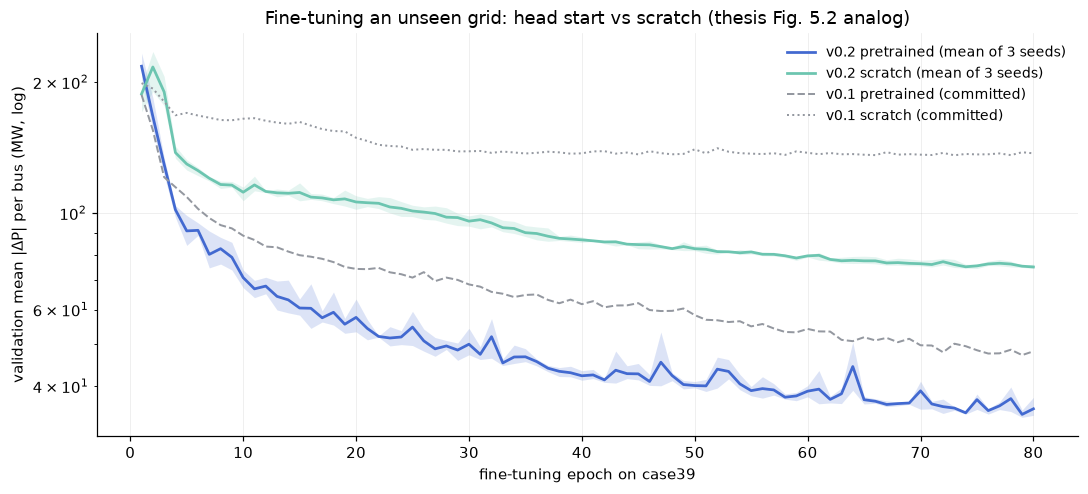

v0.2 pretrained passes scratch's final level (75.2 MW) at epoch 10

In [4]:
fig, ax = plt.subplots(figsize=(10, 4.6))
ep = np.arange(1, len(curves["pretrained"][0]) + 1)
for variant, col, name in [("pretrained", "#4269D0", "v0.2 pretrained"),
                           ("scratch", "#6CC5B0", "v0.2 scratch")]:
    arr = np.array(curves[variant])
    ax.plot(ep, arr.mean(0), lw=1.8, color=col, label=name + " (mean of 3 seeds)")
    ax.fill_between(ep, arr.min(0), arr.max(0), color=col, alpha=0.18, lw=0)
for variant, ls, name in [("pretrained", "--", "v0.1 pretrained"),
                          ("scratch", ":", "v0.1 scratch")]:
    arr = np.array(curves01[variant])
    ax.plot(np.arange(1, arr.shape[1] + 1), arr.mean(0), ls, lw=1.3,
            color="#9498A0", label=name + " (committed)")
ax.set_yscale("log")
ax.set(xlabel="fine-tuning epoch on case39", ylabel="validation mean |ΔP| per bus (MW, log)",
       title="Fine-tuning an unseen grid: head start vs scratch (thesis Fig. 5.2 analog)")
ax.legend(frameon=False, fontsize=9)
ax.grid(alpha=0.25, lw=0.5)
fig.tight_layout(); fig.savefig(FIG_DIR / "f1_ft_curves.png", bbox_inches="tight", dpi=150)
plt.show()

sc_final = float(np.array(curves["scratch"])[:, -1].mean())
pre_mean = np.array(curves["pretrained"]).mean(0)
k = int(np.argmax(pre_mean < sc_final)) + 1 if (pre_mean < sc_final).any() else -1
print("v0.2 pretrained passes scratch's final level (%.1f MW) at epoch %s" %
      (sc_final, k if k > 0 else "never"))

## Question 3 — Data efficiency: fine-tuning on a fraction of the data

pretrained +  25% data: best val Pr  50.83 MW

pretrained +  50% data: best val Pr  41.27 MW

pretrained +  75% data: best val Pr  36.69 MW

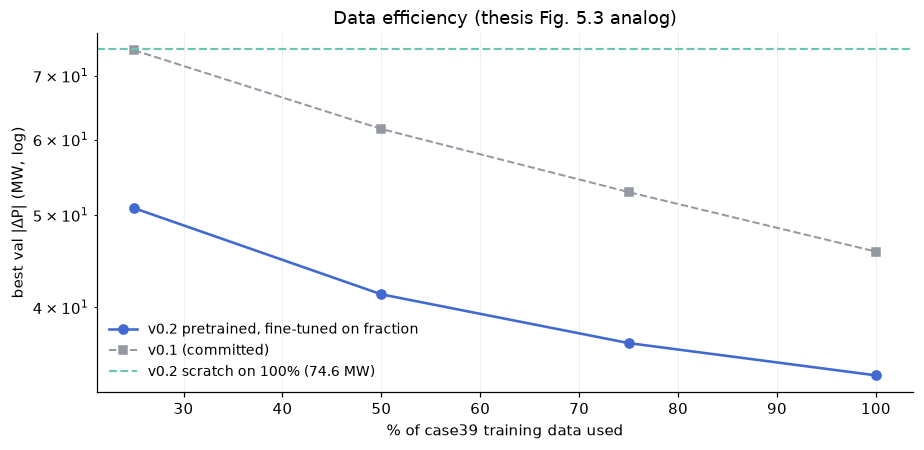

In [5]:
rng = np.random.RandomState(0)
frac_results = {}
for frac in [0.25, 0.5, 0.75]:
    idx = rng.choice(len(train39), size=int(frac * len(train39)), replace=False)
    subset = [train39[i] for i in idx]
    _, bp, _ = finetune("pretrained", subset, seed=0)
    frac_results[frac] = bp
    print("pretrained + %3.0f%% data: best val Pr %6.2f MW" % (100 * frac, bp))
frac_results[1.0] = best_states["pretrained"][0]
scratch_100 = best_states["scratch"][0]
json.dump({str(k): v for k, v in frac_results.items()},
          open(STATS_DIR / "data_efficiency.json", "w"))

fig, ax = plt.subplots(figsize=(8.5, 4.2))
fr = sorted(frac_results)
ax.plot([100 * f for f in fr], [frac_results[f] for f in fr], "o-",
        color="#4269D0", lw=1.7, ms=6, label="v0.2 pretrained, fine-tuned on fraction")
ax.plot([100 * float(f) for f in sorted(frac01, key=float)],
        [frac01[f] for f in sorted(frac01, key=float)], "s--",
        color="#9498A0", lw=1.3, ms=5, label="v0.1 (committed)")
ax.axhline(scratch_100, color="#6CC5B0", ls="--", lw=1.4,
           label="v0.2 scratch on 100%% (%.1f MW)" % scratch_100)
ax.set_yscale("log")
ax.set(xlabel="% of case39 training data used", ylabel="best val |ΔP| (MW, log)",
       title="Data efficiency (thesis Fig. 5.3 analog)")
ax.legend(frameon=False, fontsize=9)
ax.grid(alpha=0.25, lw=0.5)
fig.tight_layout(); fig.savefig(FIG_DIR / "f2_data_efficiency.png", bbox_inches="tight", dpi=150)
plt.show()

## Final scoreboard on the case39 test set

            v0.2 Pr (MW)  v0.2 Qr (MVar)  v0.1 Pr (MW)
DC solver           6.79             NaN          6.79
zero-shot         395.00          136.40        866.67
scratch            70.48           56.68        131.40
fine-tuned         30.80           33.58         41.43


thesis Table 5.4 case39 (full scale): v0.2 ft 1.86 MW vs v0.1 ft 2.21 MW; DC 13.27 MW

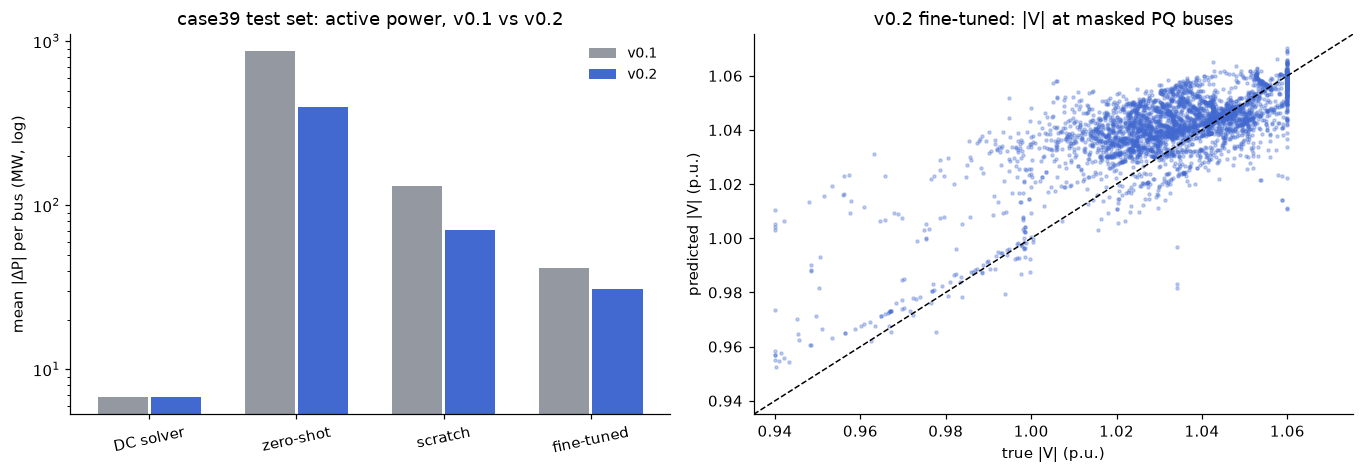

fine-tuned |V| error: mean 0.0117 p.u. | p95 0.0314 p.u.

In [6]:
def test_eval(state_dict):
    m = GridFMv02()
    m.load_state_dict(state_dict)
    df, det, _ = ev.pf_evaluate(m, test39, device=DEVICE)
    return df, det

ft_df, ft_det = test_eval(best_states["pretrained"][1])
sc_df, _ = test_eval(best_states["scratch"][1])
torch.save({"model": best_states["pretrained"][1]},
           CKPT_DIR / "final_finetune39_v02_best.pt")

score = pd.DataFrame({
    "v0.2 Pr (MW)": {"DC solver": dc39.p_res_mw.mean(),
                     "zero-shot": zs_df.p_res_mw.mean(),
                     "scratch": sc_df.p_res_mw.mean(),
                     "fine-tuned": ft_df.p_res_mw.mean()},
    "v0.2 Qr (MVar)": {"DC solver": np.nan,
                       "zero-shot": zs_df.q_res_mvar.mean(),
                       "scratch": sc_df.q_res_mvar.mean(),
                       "fine-tuned": ft_df.q_res_mvar.mean()},
    "v0.1 Pr (MW)": {"DC solver": sc01.loc["DC solver", "Pr (MW)"],
                     "zero-shot": sc01.loc["GridFM zero-shot", "Pr (MW)"],
                     "scratch": sc01.loc["GridFM scratch", "Pr (MW)"],
                     "fine-tuned": sc01.loc["GridFM fine-tuned", "Pr (MW)"]},
})
print(score.round(2).to_string())
print("\nthesis Table 5.4 case39 (full scale): v0.2 ft 1.86 MW vs v0.1 ft 2.21 MW; DC 13.27 MW")
score.to_csv(STATS_DIR / "scoreboard_case39.csv")

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))
labels = list(score.index)
x = np.arange(len(labels))
axes[0].bar(x - 0.18, score["v0.1 Pr (MW)"].values, width=0.34, color="#9498A0", label="v0.1")
axes[0].bar(x + 0.18, score["v0.2 Pr (MW)"].values, width=0.34, color="#4269D0", label="v0.2")
axes[0].set_yscale("log")
axes[0].set_xticks(x); axes[0].set_xticklabels(labels, rotation=12)
axes[0].set(ylabel="mean |ΔP| per bus (MW, log)",
            title="case39 test set: active power, v0.1 vs v0.2")
axes[0].legend(frameon=False, fontsize=9)

vm_t, vm_p = np.array(ft_det["vm_true"]), np.array(ft_det["vm_pred"])
axes[1].scatter(vm_t, vm_p, s=4, alpha=0.3, color="#4269D0")
lims = [min(vm_t.min(), vm_p.min()) - 0.005, max(vm_t.max(), vm_p.max()) + 0.005]
axes[1].plot(lims, lims, "k--", lw=1)
axes[1].set(xlabel="true |V| (p.u.)", ylabel="predicted |V| (p.u.)",
            title="v0.2 fine-tuned: |V| at masked PQ buses", xlim=lims, ylim=lims)
fig.tight_layout(); fig.savefig(FIG_DIR / "f3_final_scoreboard.png", bbox_inches="tight", dpi=150)
plt.show()

vm_err = np.abs(vm_p - vm_t)
print("fine-tuned |V| error: mean %.4f p.u. | p95 %.4f p.u."
      % (vm_err.mean(), np.percentile(vm_err, 95)))

summary = {"zero_shot": {"v02_pr_mw": float(zs_df.p_res_mw.mean()),
                         "v01_pr_mw": float(zs01.p_res_mw.mean())},
           "finetune_best_val": {v: best_states[v][0] for v in best_states},
           "scoreboard": json.loads(score.to_json()),
           "data_efficiency": {str(k): v for k, v in frac_results.items()}}
with open(STATS_DIR / "summary.json", "w") as f:
    json.dump(summary, f, indent=2)